# 01 — Análise Exploratória (EDA)

Neste notebook realizamos a **exploração e análise inicial** do dataset fornecido da nosso Tech Challege da fase 2.

O objetivo é entender a estrutura dos dados, identificar padrões, tratar possíveis inconsistências e extrair insights relevantes que sirvam de base para as próximas etapas do projeto.

### O que será feito aqui

- Carregamento e inspeção geral do dataset
- Análise de tipos de dados e valores nulos
- Estatísticas descritivas das variáveis
- Visualizações exploratórias para entender distribuições e relações entre variáveis
- Identificação de outliers e anomalias


### Instalação de bibliotecas

In [1]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

gold = pd.read_parquet("../data/gold/indicador_municipio.parquet")
gold["id_municipio"] = gold["id_municipio"].astype("int64")

print(gold.shape)
gold.head()

(44120, 18)


,id_municipio,taxa_alfabetizacao,media_portugues,taxa_meta_base,meta_2024,meta_2025,meta_2026,meta_2027,meta_2028,meta_2029,meta_2030,nivel_alfabetizacao,percentual_participacao,meta_ano_vigente,diferenca_meta,bateu_meta_2030,classificacao,ano
0,1100015,64.55,758.33,64.6,67.08,69.51,71.84,74.06,76.16,78.14,80.0,3,89.37,NaN,NaN,False,Sem meta definida,2023
1,1100023,62.30,757.10,62.3,65.22,68.02,70.71,73.25,75.65,77.90,80.0,3,89.79,NaN,NaN,False,Sem meta definida,2023
2,1100031,69.10,767.88,69.1,70.85,72.53,74.15,75.71,77.21,78.64,80.0,3,90.48,NaN,NaN,False,Sem meta definida,2023
3,1100049,64.00,758.22,62.5,65.39,68.16,70.81,73.33,75.70,77.92,80.0,3,84.44,NaN,NaN,False,Sem meta definida,2023
4,1100056,58.53,746.46,58.5,62.09,65.53,68.81,71.91,74.81,77.51,80.0,2,92.12,NaN,NaN,False,Sem meta definida,2023


In [32]:
gold.info()

<class 'pandas.DataFrame'>
RangeIndex: 44120 entries, 0 to 44119
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_municipio             44120 non-null  str    
 1   taxa_alfabetizacao       44120 non-null  float64
 2   media_portugues          44120 non-null  float64
 3   taxa_meta_base           42336 non-null  float64
 4   meta_2024                41856 non-null  float64
 5   meta_2025                42684 non-null  float64
 6   meta_2026                42684 non-null  float64
 7   meta_2027                42684 non-null  float64
 8   meta_2028                42684 non-null  float64
 9   meta_2029                42684 non-null  float64
 10  meta_2030                42684 non-null  float64
 11  nivel_alfabetizacao      42336 non-null  str    
 12  percentual_participacao  42336 non-null  float64
 13  meta_ano_vigente         20928 non-null  float64
 14  diferenca_meta           20928 no

## 2.1 Visão geral das variáveis

In [33]:
gold.describe().T

,count,mean,std,min,25%,50%,75%,max
taxa_alfabetizacao,44120.0,61.968573,19.280117,4.4,48.0,62.63,76.74,100.0
media_portugues,44120.0,752.100744,23.087014,673.3,736.84,751.2,764.64,868.46
taxa_meta_base,42336.0,61.774719,19.526848,4.4,47.6,62.445,76.7425,100.0
meta_2024,41856.0,62.151745,15.09692,7.94,52.17,64.095,75.885,80.0
meta_2025,42684.0,65.268532,12.617223,14.05,57.19,66.96,76.55,80.0
meta_2026,42684.0,68.57597,9.843218,23.65,62.46,69.9,77.27,80.0
meta_2027,42684.0,71.784966,7.051471,37.0,67.44,72.68,77.98,80.0
meta_2028,42684.0,74.802936,4.395097,52.68,72.06,75.3,78.67,80.0
meta_2029,42684.0,77.55584,2.015881,67.85,76.26,77.74,79.34,80.0
meta_2030,42684.0,80.0,0.0,80.0,80.0,80.0,80.0,80.0


## 2.2 Nulos por coluna

`meta_ano_vigente`/`diferenca_meta` têm nulos em 2023 porque as metas só
existem a partir de 2024.

In [34]:
(gold.isna().mean() * 100).round(1).sort_values(ascending=False).to_frame("% nulos")

,% nulos
meta_ano_vigente,52.6
diferenca_meta,52.6
meta_2024,5.1
percentual_participacao,4.0
nivel_alfabetizacao,4.0
taxa_meta_base,4.0
meta_2030,3.3
meta_2029,3.3
meta_2025,3.3
meta_2026,3.3


## 2.3 Distribuição da taxa de alfabetização

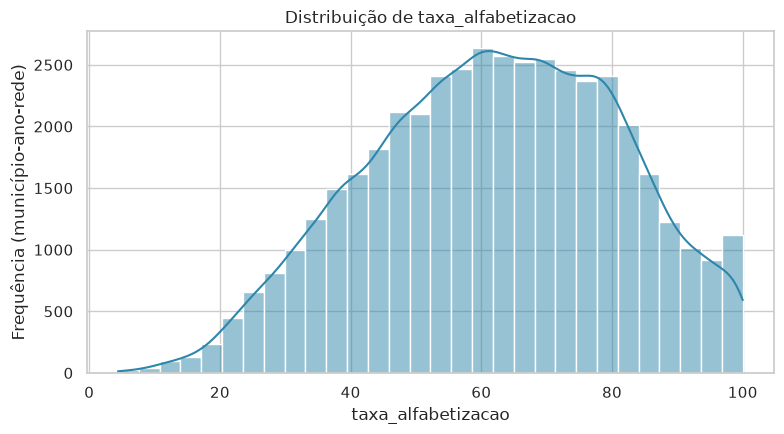

In [35]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(gold["taxa_alfabetizacao"].dropna(), bins=30, kde=True, color="#2E86AB", ax=ax)
ax.set_title("Distribuição de taxa_alfabetizacao")
ax.set_xlabel("taxa_alfabetizacao")
ax.set_ylabel("Frequência (município-ano-rede)")
plt.tight_layout()
plt.show()

**Leitura:** distribuição ampla, de perto de 0% a quase 100%, com maior
concentração na faixa de 55-75% — bastante heterogeneidade.

## 2.4 Evolução da taxa média nacional (2023 → 2024)

           mean  median        std
ano                               
2023  60.707370   61.30  19.525610
2024  63.229318   64.23  18.948272


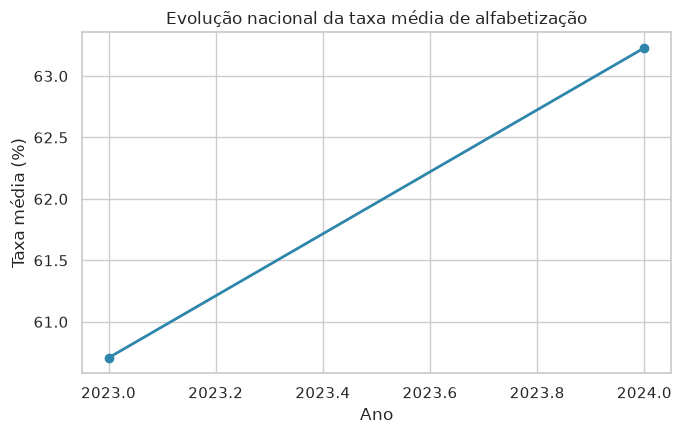

In [23]:
evolucao = gold.groupby("ano")["taxa_alfabetizacao"].agg(["mean", "median", "std"])
print(evolucao)

fig, ax = plt.subplots(figsize=(7, 4.5))
serie = gold.groupby("ano")["taxa_alfabetizacao"].mean()
ax.plot(serie.index, serie.values, marker="o", linewidth=2, color="#2E86AB")
ax.set_title("Evolução nacional da taxa média de alfabetização")
ax.set_xlabel("Ano")
ax.set_ylabel("Taxa média (%)")
plt.tight_layout()
plt.show()

**Leitura:** a taxa média nacional subiu de 2023 para 2024 — sinal
positivo, mas ainda distante da meta de 80% até 2030.

## 2.5 Correlação entre variáveis numéricas

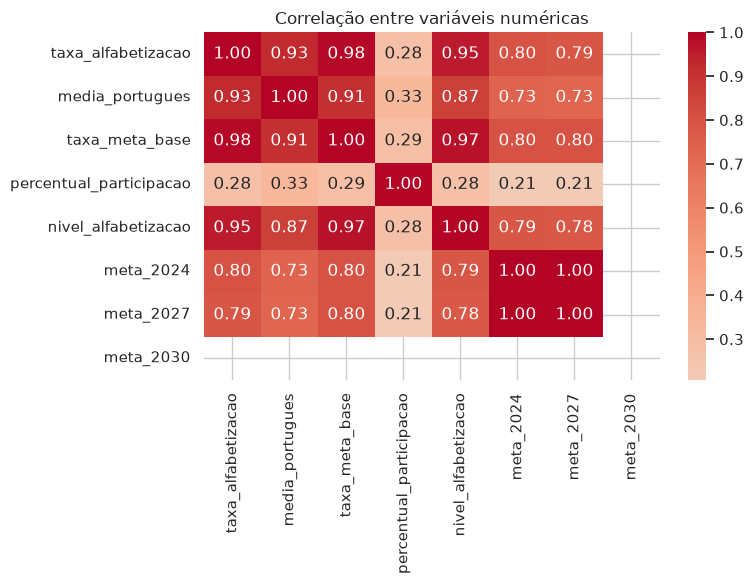

In [36]:
numeric_cols = [
    "taxa_alfabetizacao", "media_portugues", "taxa_meta_base",
    "percentual_participacao", "nivel_alfabetizacao",
    "meta_2024", "meta_2027", "meta_2030",
]

fig, ax = plt.subplots(figsize=(8, 6))
corr = gold[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

**Leitura importante para a modelagem (notebook 03):**
- `taxa_meta_base` (r ≈ 0.98) e `media_portugues` (r ≈ 0.93) são
  quase-cópias da própria `taxa_alfabetizacao` — não podem virar features
  do modelo (data leakage).
- `nivel_alfabetizacao` também é essencialmente um balde da taxa.
- `percentual_participacao` tem correlação baixa (~0.28) — feature legítima.
- As metas (`meta_2024`...`meta_2030`) têm correlação moderada (~0.80), mas
  são valores de política pública conhecidos a priori — podem ser feature.

## 2.6 Ranking de municípios: maior e menor taxa (2024)

**Base IBG - API pública** : O IBGE disponibiliza uma API gratuita e oficial com todos os municípios do Brasil (código + nome + UF). Vamos utilizar ela para identificação dos municípios e UFs da base.

In [37]:
import requests

resp = requests.get("https://servicodados.ibge.gov.br/api/v1/localidades/municipios")
municipios_ibge = pd.DataFrame(resp.json())[["id", "nome"]].rename(
    columns={"id": "id_municipio", "nome": "nome_municipio"}
)
print(municipios_ibge.shape)
municipios_ibge.head()

(5571, 2)


,id_municipio,nome_municipio
0,1100015,Alta Floresta D'Oeste
1,1100023,Ariquemes
2,1100031,Cabixi
3,1100049,Cacoal
4,1100056,Cerejeiras


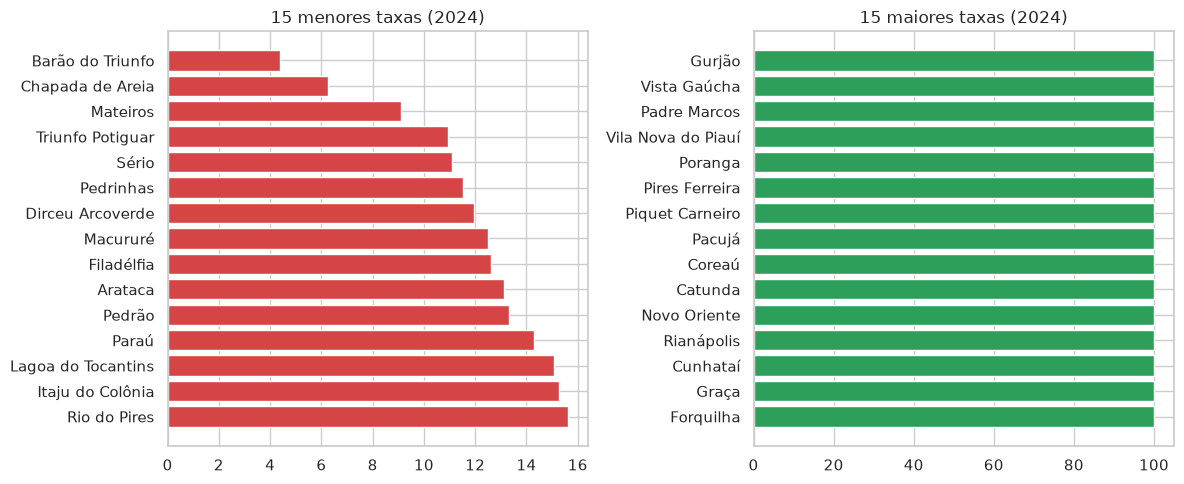

In [54]:
gold_2024 = (
    gold[gold["ano"] == 2024]
    .drop_duplicates(subset=["id_municipio"])
    .merge(municipios_ibge, on="id_municipio", how="left")
)
ranked = gold_2024.sort_values("taxa_alfabetizacao")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bottom = ranked.head(15)
axes[0].barh(bottom["nome_municipio"], bottom["taxa_alfabetizacao"], color="#D64545")
axes[0].set_title("15 menores taxas (2024)")
axes[0].invert_yaxis()

top = ranked.tail(15).sort_values("taxa_alfabetizacao", ascending=False)
axes[1].barh(top["nome_municipio"], top["taxa_alfabetizacao"], color="#2E9E5B")
axes[1].set_title("15 maiores taxas (2024)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 2.7 Classificação em relação à meta, por ano

classificacao  Abaixo da meta  Acima da meta  Muito abaixo da meta  Na meta  \
ano                                                                           
2023                        0              0                     0        0   
2024                     3044           8252                  6588     3044   

classificacao  Sem meta definida  
ano                               
2023                       22056  
2024                        1136  


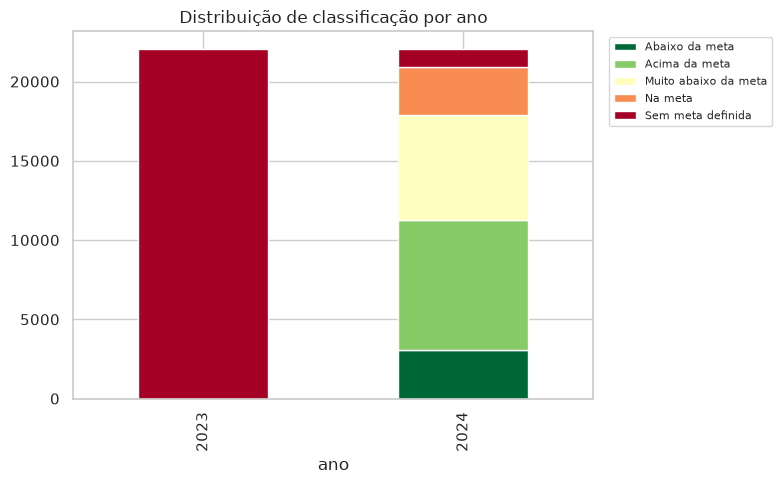

In [55]:
ct = pd.crosstab(gold["ano"], gold["classificacao"])
print(ct)

fig, ax = plt.subplots(figsize=(8, 5))
ct.plot(kind="bar", stacked=True, ax=ax, colormap="RdYlGn_r")
ax.set_title("Distribuição de classificação por ano")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 2.8 Hipóteses analíticas (para testar na modelagem)

1. **H1 — Participação isolada tem pouco poder preditivo**: `percentual_participacao`
   tem correlação fraca (~0.28) com a taxa (seção 2.5). Sozinha não deve
   carregar o modelo.
2. **H2 — As metas de política pública carregam sinal estrutural real**:
   `meta_2024`...`meta_2030` têm correlação moderada (~0.80) com a taxa e
   são conhecidas a priori (definidas por política pública, não medidas
   após o fato) — candidatas legítimas a feature.
3. **H3 — `diferenca_meta` e `bateu_meta_2030` são rótulos derivados, não
   features**: ambos são calculados a partir da própria `taxa_alfabetizacao`
   frente à meta vigente, então usá-los como input vaza o alvo.
4. **H4 — A heterogeneidade entre municípios domina a evolução temporal**:
   a média nacional subiu de 2023 para 2024 (seção 2.4), mas o intervalo
   entre os 15 municípios com maior e menor taxa (seção 2.6) é muito maior
   que esse ganho ano a ano — o modelo deve ter um teto de performance
   moderado, limitado por essa variância estrutural entre municípios.